# Análisis del dataset Adult Census Income

**Objetivo:** predecir si una persona gana más o menos de USD 50.000 anuales a partir de variables demográficas y laborales (dataset *Adult* de UCI Machine Learning Repository), aplicando un proceso completo de limpieza, preprocesamiento, clasificación (Decision Tree) y clustering (DBSCAN). Se incluye además un análisis de los riesgos éticos y de privacidad asociados al uso de este tipo de datos.

**Herramientas:** Python, pandas, scikit-learn, matplotlib, seaborn.

**Fuente de datos:** [UCI Machine Learning Repository - Adult Data Set](https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data)


In [ ]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
df = pd.read_csv(url, names=columns, na_values=' ?', skipinitialspace=True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_samples, silhouette_score, confusion_matrix, accuracy_score, precision_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
for column in df.columns:
    print(f"Unique values for '{column}':\n{df[column].unique()}\n")

Unique values for 'age':
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]

Unique values for 'workclass':
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

Unique values for 'fnlwgt':
[ 77516  83311 215646 ...  34066  84661 257302]

Unique values for 'education':
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

Unique values for 'education-num':
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]

Unique values for 'marital-status':
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

Unique values for 'occupation':
['Adm-clerical' 'Exec-managerial' 'Handlers-clea

## 1. Tratamiento de valores nulos

Paso los valores faltantes '?' a nulos antes de eliminarlos o trabajarlos, para que sea un procedimiento más estandard

In [ ]:
df = df.replace('?', pd.NA)

In [ ]:
for column in df.columns:
    print(f"Unique values for '{column}':\n{df[column].unique()}\n")

Unique values for 'age':
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]

Unique values for 'workclass':
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' <NA>
 'Self-emp-inc' 'Without-pay' 'Never-worked']

Unique values for 'fnlwgt':
[ 77516  83311 215646 ...  34066  84661 257302]

Unique values for 'education':
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

Unique values for 'education-num':
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]

Unique values for 'marital-status':
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

Unique values for 'occupation':
['Adm-clerical' 'Exec-managerial' 'Handlers-cle

In [ ]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
#Elimino los nulos
print(f"Filas antes de eliminar: {len(df)}")

df_clean = df.dropna().copy()  # elimina cualquier fila con al menos un nulo

print(f"Filas despues de eliminar: {len(df_clean)}")
print(f"Filas eliminadas: {len(df) - len(df_clean)}")

Filas antes de eliminar: 32561
Filas despues de eliminar: 30162
Filas eliminadas: 2399


In [ ]:
df_clean.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


Se eliminaron 2399 filas. Es una cantidad moderada aunque no
despreciable, se decide igual eliminarlas porque, como se analiza más abajo, los
nulos no son aleatorios, tienen una explicación lógica razonable, y el dataset resultante sigue siendo suficientemente grande para el análisis

Otras opciones para reemplazar los nulos sería:


*   Para las variables numericas, podrían reemplazarse con la mediana, que es mejor parámetro que, por ejemplo, el promedio, ya que no altera los outliears.
*   En el caso de las variables categoricas, una opcion podría ser reemplazar los valores categoricos por la moda, que al ser el valor que más se repite, mantiene la tendencia de los datos. También pueden reemplazarse datos basandose en otras columnas que se relacionen con la columna que se está tratando.

En ambos casos, también puede reemplazar el nulo por una etiqueta tipo "desconocido" o "sin dato", dependiendo de la evaluación de lsa variables

### Análisis adicional: relación entre nulos de 'workclass' y 'occupation'

Quise ver si los nulos en "workclass" y en "occupation" tenian relacion entre si.

In [ ]:
# Verifico si los nulos de workclass coinciden con nulos en occupation
print(df[df['workclass'].isnull()]['occupation'].isnull().sum())
print(df['workclass'].isnull().sum())

1836
1836


In [ ]:
mask = df['occupation'].isnull() & df['workclass'].notnull()
df[mask][['workclass', 'occupation']]

,workclass,occupation
5361,Never-worked,<NA>
10845,Never-worked,<NA>
14772,Never-worked,<NA>
20337,Never-worked,<NA>
23232,Never-worked,<NA>
32304,Never-worked,<NA>
32314,Never-worked,<NA>


Veo que las 1836 filas sin "workclass" son exactamente las mismas que no tienen "occupation", o sea, el mismo grupo de personas que no reportó nada sobre su situación laboral, tampoco tienen un empleo formal. También noté que 7 nulos de "occupation" corresponden a personas con "workclass": "Never-worked", como nunca trabajaron, no hay ocupación.
Veo que los valores nulos no son al azar, sino que está relacionado con la situación laboral real de esas personas. Por eso, si en vez de eliminar hubiera reemplazados los valores, en este caso no habría usado la moda porque estaría inventando que esas personas trabajan, cuando parece que no, y eso podría arruinar el analisis. Asi que haría una categoría nueva que sea "Desconocido".

## 2. Detección y tratamiento de outliers

In [ ]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
age,30162.0,38.437902,13.134665,17.0,28.00,37.0,47.0,90.0
fnlwgt,30162.0,189793.833930,105652.971529,13769.0,117627.25,178425.0,237628.5,1484705.0
education-num,30162.0,10.121312,2.549995,1.0,9.00,10.0,13.0,16.0
capital-gain,30162.0,1092.007858,7406.346497,0.0,0.00,0.0,0.0,99999.0
capital-loss,30162.0,88.372489,404.298370,0.0,0.00,0.0,0.0,4356.0
hours-per-week,30162.0,40.931238,11.979984,1.0,40.00,40.0,45.0,99.0


In [ ]:
v_num = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

In [ ]:
#evaluo las variables numericas, elimino fnlwgt porque no suma al analisis

for col in v_num:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df_clean)*100}%) | límites: [{lower}, {upper}]")

age: 169 outliers (0.560307671905046%) | límites: [-0.5, 75.5]
education-num: 196 outliers (0.6498242822094025%) | límites: [3.0, 19.0]
capital-gain: 2538 outliers (8.41456136860951%) | límites: [0.0, 0.0]
capital-loss: 1427 outliers (4.731118626085803%) | límites: [0.0, 0.0]
hours-per-week: 7953 outliers (26.367614879649892%) | límites: [32.5, 52.5]


Los limites de capital-gain y capital-loss dan 0, esto pasa porque el Q1, la mediana y el Q3 de esas columnas son 0 (más del 90% de los valores son cero), entonces el IQR es 0 y cualquier valor diferente queda marcado como outlier. No los elimino, pero el análisis correcto es el de la celda 23 (153 y 53 outliers reales sobre los valores no-cero).

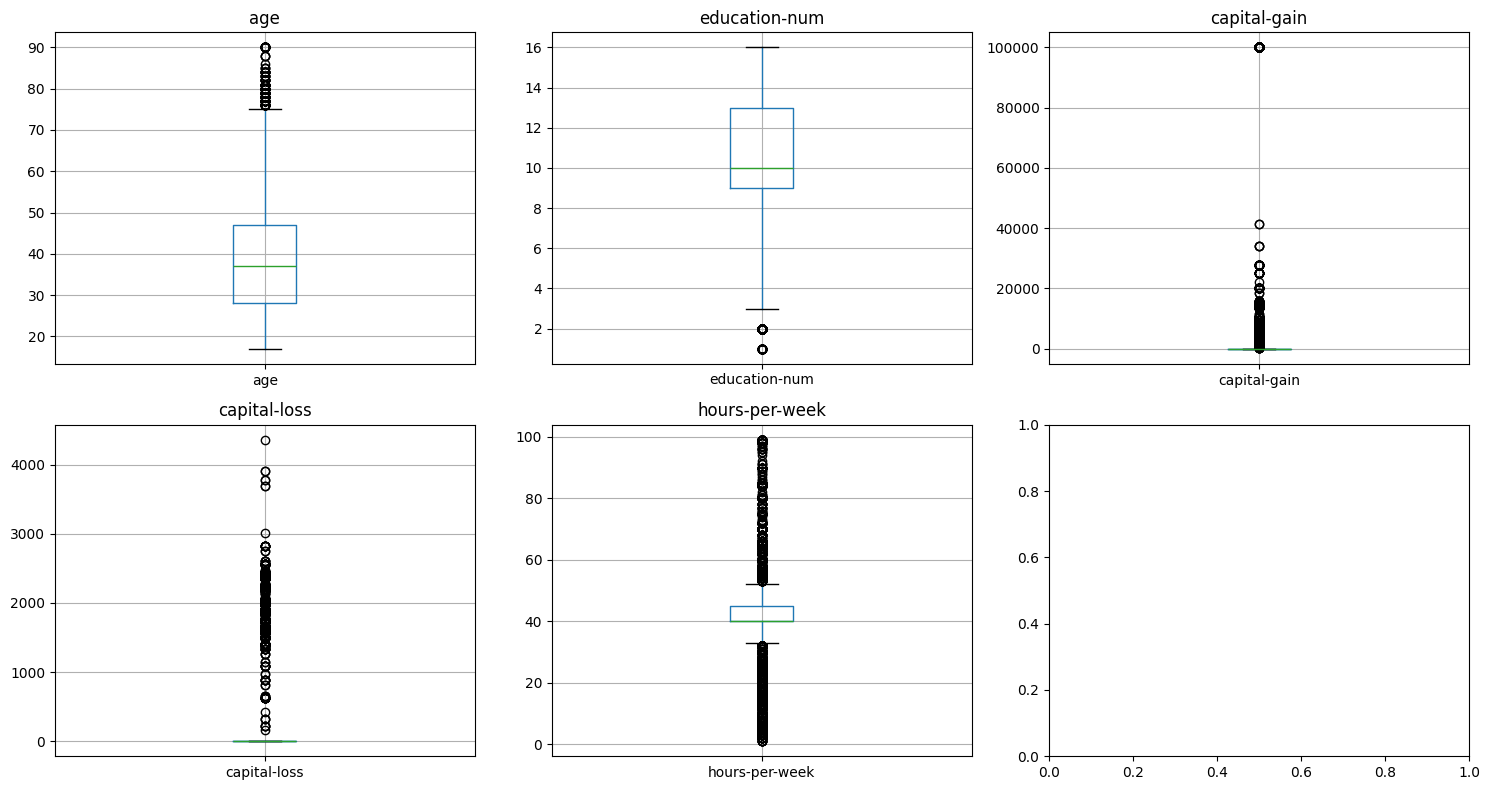

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), v_num):
    df_clean.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
# En capital-gain y capital-loss: la mayoría son cero, reviso aparte
for col in ['capital-gain', 'capital-loss']:
    zero_pct = (df_clean[col] == 0).mean() * 100
    print(f"{col}: {zero_pct:.1f}% son ceros")

for col in ['capital-gain', 'capital-loss']:
    nonzero = df_clean[df_clean[col] > 0][col]
    Q1 = nonzero.quantile(0.25)
    Q3 = nonzero.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    outliers = nonzero[nonzero > upper]
    print(f"{col}: sobre {len(nonzero)} valores no-cero, {len(outliers)} outliers, límite superior: {upper:.1f}")


capital-gain: 91.6% son ceros
capital-loss: 95.3% son ceros
capital-gain: sobre 2538 valores no-cero, 153 outliers, límite superior: 30014.0
capital-loss: sobre 1427 valores no-cero, 53 outliers, límite superior: 2434.5


Sí hay outliers, pero no los elimino porque la mayoría parecen ser valores reales
(ganancias o pérdidas reales), y el pico repetido en 99999 parece ser un tope impuesto por el propio censo, no un error.
Eliminar esas filas sería sacar información real y sesgar la muestra. En "age" los outliers también corresponderían a casos reales (gente mayor trabajando, por ejemplo), así que tampoco los elimino.
En hours-per-week, el 26.4% de outliers detectados por IQR es un número alto,
pero se debe a que la distribución está muy concentrada alrededor de las 40 horas, lo que genera límites muy estrictos. Esto no refleja valores extremos reales, sino la naturaleza de la distribución: trabajar medio tiempo o hacer horas extra es común en una población real, no un error. Por eso no se elimina ningún registro de esta columna.

## 3. Codificación de la variable objetivo (Label Encoding)

In [ ]:
le = LabelEncoder()
df_clean['income_encoded'] = le.fit_transform(df_clean['income'])

print(dict(zip(le.classes_, le.transform(le.classes_))))
df_clean[['income', 'income_encoded']].head()

{'<=50K': np.int64(0), '>50K': np.int64(1)}


,income,income_encoded
0,<=50K,0
1,<=50K,0
2,<=50K,0
3,<=50K,0
4,<=50K,0


In [ ]:
df_clean

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_encoded
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,0
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,1
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,0
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K,0


## 4. Preprocesamiento final (One-Hot Encoding y selección de variables)

In [ ]:
df_model = df_clean.drop(columns=['education', 'fnlwgt', 'income'])
"""'education' se elimina porque es redundante con 'education-num', 'fnlwgt' se elimina porque no una característica de la persona,
'income' se elimina porque ya tengo su equivalente numérico"""

# Label Encoding para 'sex' ---
le_sex = LabelEncoder()
df_model['sex'] = le_sex.fit_transform(df_model['sex'])

# One-Hot Encoding para el resto de las categóricas
cat_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']

ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe.set_output(transform="pandas")
v_cat = ohe.fit_transform(df_model[cat_cols])

v_num = df_model.drop(columns=cat_cols)

df_model = pd.concat([v_num, v_cat], axis=1)

print(df_model.shape)
df_model.head()

(30162, 81)


,age,education-num,sex,capital-gain,capital-loss,hours-per-week,income_encoded,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,13,1,2174,0,40,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,50,13,1,0,0,13,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,38,9,1,0,0,40,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,53,7,1,0,0,40,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,28,13,0,0,0,40,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Problema de aplicar One-Hot Encoding es que las columnas con muchas categorías van a generar muchas columnas nuevas, aumentando mucho la dimensionalidad. La alternativa, Label Encoding, evitaría esto, pero crearia un orden artificial entre categorías que no existe en la realidad.

## 5. División en conjuntos de entrenamiento y test

In [ ]:
X = df_model.drop(columns=['income_encoded'])

In [ ]:
y = df_model['income_encoded']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(24129, 80) (6033, 80)
income_encoded
0    0.751088
1    0.248912
Name: proportion, dtype: float64


Elegí 80% / 20% porque el dataset es muy grande, lo que permite dejar un 20% como test sin resignar demasiados datos de entrenamiento. Usé
stratify=y porque las clases de income están desbalanceadas (76%/24%), y así mantengo esa proporción en ambos conjuntos.

## 6. Entrenamiento y evaluación de modelos

### 6.1 Árbol de decisión (Decision Tree)

In [ ]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

y_pred_dt = dt_clf.predict(X_test)

El Decision Tree es un modelo facil de interpretar, no requiere escalado de variables, maneja bien variables numéricas y categóricas, pero es propenso a overfitting, y tiene alta varianza, es sensible a pequeños cambios en
los datos de entrenamiento.
Un posible reemplazo sería Random Forest, un conjunto de múltiples árboles entrenados sobre subconjuntos aleatorios de datos y variables, que reduce el overfitting y la varianza manteniendo de la interpretabilidad.

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)
print("Matriz de confusión:")
print(cm)

acc = accuracy_score(y_test, y_pred_dt)
print(f"\nAccuracy: {acc}")

prec = precision_score(y_test, y_pred_dt)
print(f"Precision: {prec}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Matriz de confusión:
[[3998  533]
 [ 558  944]]

Accuracy: 0.8191612796287088
Precision: 0.6391333784698714

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4531
           1       0.64      0.63      0.63      1502

    accuracy                           0.82      6033
   macro avg       0.76      0.76      0.76      6033
weighted avg       0.82      0.82      0.82      6033



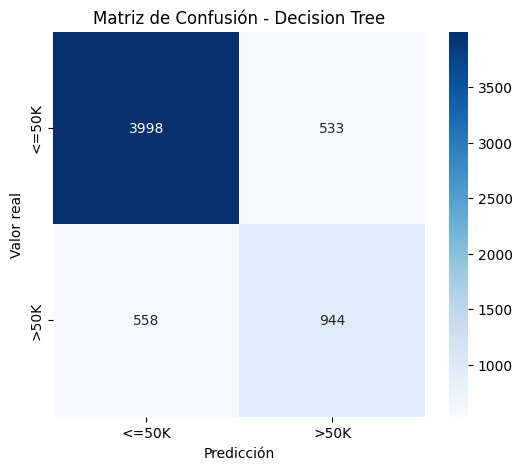

In [ ]:
# Visualización de la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Decision Tree')
plt.show()

El modelo dio un accuracy de 0.82, o sea que acierta 8 de cada 10 veces.
Pero este número solo no dice mucho porque las clases están desbalanceadas (75% gana <=50K y 25% gana más), así que un modelo que prediga siempre <=50K ya tendría un accuracy parecido sin haber aprendido nada en realidad.
Por eso miré las métricas separadas por clase. Para <=50K el modelo anda bien
(precision y recall de 0.88), pero para >50K baja bastante: precision de 0.64 y
recall de 0.63. Esto quiere decir que de las personas que el modelo dice que ganan más de 50K, casi 4 de cada 10 en realidad no ganan tanto, y que se le escapan un 37% de los casos reales de >50K (los clasifica mal, como si ganaran menos).
Se ve en la matriz de confusión: de 1502 casos reales de >50K, acertó 944
pero se equivocó en 558. Tiene sentido que pase esto, porque el dataset tiene menos ejemplos de gente que gana más de 50K, entonces el modelo tuvo menos con qué aprender ese patrón. Si quisiera querés corregir esto, lo primero que tendría que hacer es mirar el balance de clases y probar sobremuestreo o submuestreo, antes de tocar otra cosa.

### 6.2 Clustering con DBSCAN (variables escaladas + PCA)

In [ ]:
# Escalado
# Necesario porque las variables tienen rangos muy distintos entre sí
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# PCA a 2 componentes
# Para reducir la dimensionalidad antes de DBSCAN. Para poder graficar los clusters en un plano
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Varianza explicada por las 2 componentes: {pca.explained_variance_ratio_.sum()}")

# DBSCAN
dbscan = DBSCAN(eps=0.05, min_samples=50)
labels = dbscan.fit_predict(X_pca)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido: {n_noise} ({n_noise/len(labels):.2%})")

Varianza explicada por las 2 componentes: 0.2734273367314217
Clusters encontrados: 34
Puntos de ruido: 2796 (9.27%)


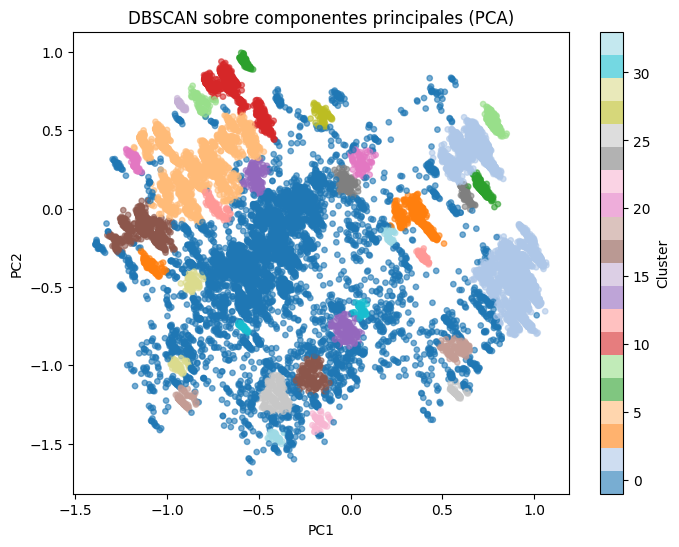

In [ ]:
# Gráfico
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab20', s=15, alpha=0.6)
plt.title('DBSCAN sobre componentes principales (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [ ]:
# Evaluación con Silhouette Score
# Lo aplico directo sobre el resultado de DBSCAN, excluyendo el ruido porque no pertenece a ningún cluster real
mask = labels != -1
score = silhouette_score(X_pca[mask], labels[mask])
print(f"Silhouette score: {score}")

Silhouette score: 0.31764806548858426


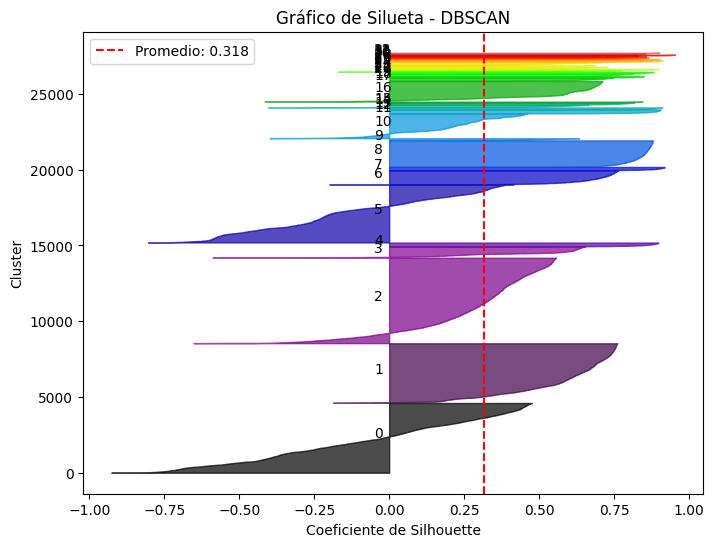

In [ ]:
#Grafico de silueta
X_filtrado = X_pca[mask]
labels_filtrado = labels[mask]

sample_silhouette_values = silhouette_samples(X_filtrado, labels_filtrado)
clusters_unicos = np.unique(labels_filtrado)
n_clusters_plot = len(clusters_unicos)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10

for idx, i in enumerate(clusters_unicos):
    valores_cluster_i = np.sort(sample_silhouette_values[labels_filtrado == i])
    tamano_cluster_i = len(valores_cluster_i)
    y_upper = y_lower + tamano_cluster_i

    color = plt.cm.nipy_spectral(float(idx) / n_clusters_plot)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, valores_cluster_i,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * tamano_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=score, color="red", linestyle="--", label=f"Promedio: {score:.3f}")
ax.set_title("Gráfico de Silueta - DBSCAN")
ax.set_xlabel("Coeficiente de Silhouette")
ax.set_ylabel("Cluster")
ax.legend()
plt.show()

Para poder aplicar DBSCAN tuve que escalar las variables y
reducir todo a 2 componentes con PCA, porque si no, variables como capital-gain
iban a pesar mucho más que las demás en el cálculo de distancias, y además así
podía graficarlo.

Aclaración, las 2 componentes solo explican el 27% de la
varianza total, o sea que se pierde bastante información al comprimir todo a 2
dimensiones nada más.
Con eps=0.05 y min_samples=50 me dio 34 clusters, y un 9.27% de los puntos quedaron como ruido. El silhouette dio 0.318, que no está mal
pero tampoco es un resultado espectacular, indica que los clusters están separados, pero no de forma muy marcada.

En el gráfico de silueta se ve que no todos los clusters están igual de bien
formados: algunos tienen coeficientes altos (grupos bastante compactos y
diferenciados) y otros más bajos, casi en cero, que son clusters que se pisan un
poco con los de al lado.

A diferencia del árbol de decisión, acá DBSCAN no sabe nada de "income", solo agrupa gente parecida entre sí según sus otras características. El resultado (34 grupos, sin que ninguno domine claramente, con separación media), muestra que la población del censo no se divide en pocos bloques bien marcados, sino en varios subgrupos más chicos con perfiles un poco distintos. Igual, como el PCA se quedó con poca varianza explicada, esta conclusión hay que tomarla con pinzas, no como algo definitivo.

### Comparación adicional: DBSCAN sin PCA (sobre las variables originales)

In [ ]:
# Se usa una muestra de 3000 puntos

# Muestra aleatoria reproducible
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=3000, replace=False)
X_sample_full = X_scaled[sample_idx]

# Barrido de eps para encontrar un valor razonable
for eps_val in [1.1, 1.2, 1.3, 1.4]:
    db = DBSCAN(eps=eps_val, min_samples=50)
    lab = db.fit_predict(X_sample_full)
    n_clust = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise_pct = (list(lab).count(-1) / len(lab)) * 100
    print(f"eps={eps_val}: {n_clust} clusters, {n_noise_pct}% ruido")

print()

# DBSCAN final con el eps elegido
dbscan_full = DBSCAN(eps=1.2, min_samples=50)
labels_sample = dbscan_full.fit_predict(X_sample_full)

n_clusters_sample = len(set(labels_sample)) - (1 if -1 in labels_sample else 0)
n_noise_sample = list(labels_sample).count(-1)
print(f"Clusters: {n_clusters_sample}")
print(f"Ruido: {n_noise_sample} ({n_noise_sample/len(labels_sample)})")

# Silhouette score sobre la muestra (excluyendo ruido)
mask_sample = labels_sample != -1
score_sample = silhouette_score(X_sample_full[mask_sample], labels_sample[mask_sample])
print(f"Silhouette (muestra, sin PCA): {score_sample:}")

eps=1.1: 5 clusters, 34.9% ruido
eps=1.2: 5 clusters, 33.4% ruido
eps=1.3: 5 clusters, 33.166666666666664% ruido
eps=1.4: 5 clusters, 33.1% ruido

Clusters: 5
Ruido: 1002 (0.334)
Silhouette (muestra, sin PCA): 0.24343224634441185


probé aplicar DBSCAN directamente sobre las 80 variables
originales (sin PCA), usando una muestra de 3000 puntos por el tiempo que tardaba con el dataset completo. Con eps=1.2 y min_samples=50 me dio 5 clusters, con un 33.40% de ruido (1002 puntos) y un silhouette de 0.243.

Comparando con la versión que usé antes (con PCA, eps=0.05,
min_samples=50): 34 clusters, 9.27% de ruido, silhouette de 0.318, la versión con PCA da mejores resultados en las dos métricas que importan: menos ruido y mejor separación entre clusters. Sin PCA, casi un tercio de los puntos no logra agruparse en ningún cluster, y el silhouette es más bajo.

## Conclusiones

- Tras la limpieza (eliminación de nulos en 'workclass', 'occupation' y 'native-country') se trabajó con un dataset reducido pero consistente, sin introducir sesgos relevantes ya que los nulos no se concentraban en una clase particular de ingreso.
- El **Decision Tree** alcanzó un accuracy de 0.82, aceptable como primer modelo base, aunque insuficiente por sí solo dado el desbalance de clases del dataset (se recomienda complementar con métricas como precision/recall o F1 por clase).
- El **DBSCAN** con reducción PCA permitió identificar agrupamientos naturales en los datos, aunque con pérdida de interpretabilidad de las variables originales; la comparación sin PCA confirmó que la reducción de dimensionalidad era necesaria para obtener clusters interpretables en tiempos razonables.
- El análisis ético señala que variables como *race*, *sex* y *native-country* requieren tratamiento cuidadoso para evitar tanto la identificación indirecta de personas como el uso discriminatorio de las predicciones del modelo en contextos sensibles (ej. crédito, contratación).
